In [1]:
import os
from scipy.io import wavfile
import numpy as np
import torch
import librosa
import matplotlib.pyplot as plt

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("Using the GPU!")
else:
    print("WARNING: Could not find GPU. Using CPU only.")
    
# load config file
from whale_gunshot_localization import config
from whale_gunshot_localization.utils.experimental import l2_standardize, MultilaterationOpt
from whale_gunshot_localization.models.tcn_archs import TCNRangeAndClassify

Using the GPU!


In [2]:
files = ['gunshot_1_1.wav','gunshot_1_2.wav','gunshot_1_3.wav','gunshot_1_4.wav']

load model

In [3]:
model = TCNRangeAndClassify(input_size=232,          # 232 channel spectrograms
                            num_channels=7*[368],
                            kernel_size=6,
                            dropout=0.3).to(device)

# load model weights
state_dict = torch.load(os.path.join(config['models']['checkpoints_directories'], config['models']['model_dir'], 'weights_best.pt'),
                       map_location=device)['model_state_dict']
model.load_state_dict(state_dict)
model.eval();

load and preprocess audio

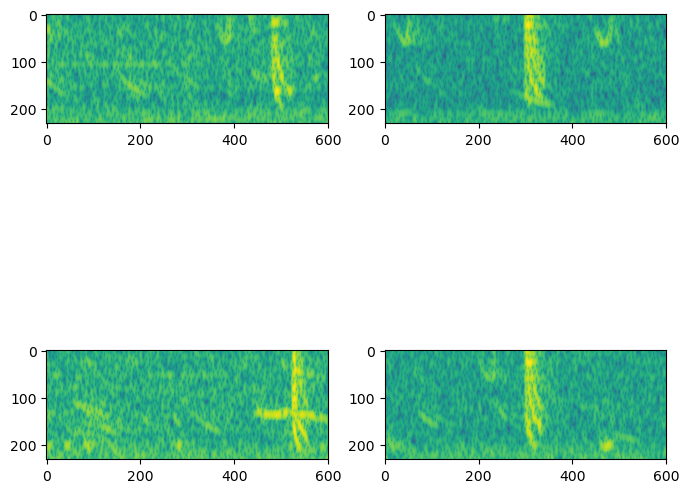

In [45]:
mu_list = np.load(config['dataset']['data_directory'] + '/mean_range_classification.npy', allow_pickle=True)
mu_list = np.expand_dims(mu_list, axis=-1)

std_list = np.load(config['dataset']['data_directory'] + '/std_range_classification.npy', allow_pickle=True)
std_list = np.expand_dims(std_list, axis=-1)

ranges = []
with torch.set_grad_enabled(False):
    for i, f in enumerate(files):
        y,_ = librosa.load(f,sr=600)
        y = l2_standardize(np.expand_dims(y,axis=(0,1)), mu_list, std_list).squeeze(axis=0)
        if i == 0:
            inputs = torch.zeros(len(files),y.shape[1],y.shape[2])
        inputs[i,...] = y
    out = model(inputs.to(device)).squeeze().to('cpu')
ranges = out[:,0]*config['scaling']['max_r']

rows = int(np.floor(np.sqrt(inputs.shape[0])));
columns = int(np.ceil(inputs.shape[0]/rows));
f, axs = plt.subplots(rows,columns)
c = 0
for ax1 in axs:
    for ax2 in ax1:
        ax2.imshow(inputs[c,...])
        c += 1

In [49]:
def localize(r_p, sensors_idx):
    
    # TOSSITs
    TOSSIT_locations = np.asarray([config['TOSSIT']['TOSSIT_y'], config['TOSSIT']['TOSSIT_x']]).T

    ML = MultilaterationOpt(method_thresh=float('inf'))
    # set geometry
    ML.set_map({
        'TOSSIT_locations' : TOSSIT_locations,
        'min_x' : config['scaling']['min_x'],
        'max_x' : config['scaling']['max_x'],
        'min_y' : config['scaling']['min_y'],
        'max_y' : config['scaling']['max_y'],
    })
        
    _, loc = ML.localize(r_p, sensors_idx)
            
    return loc
loc = localize(np.asarray(ranges), np.asarray([0, 1, 2, 3]))

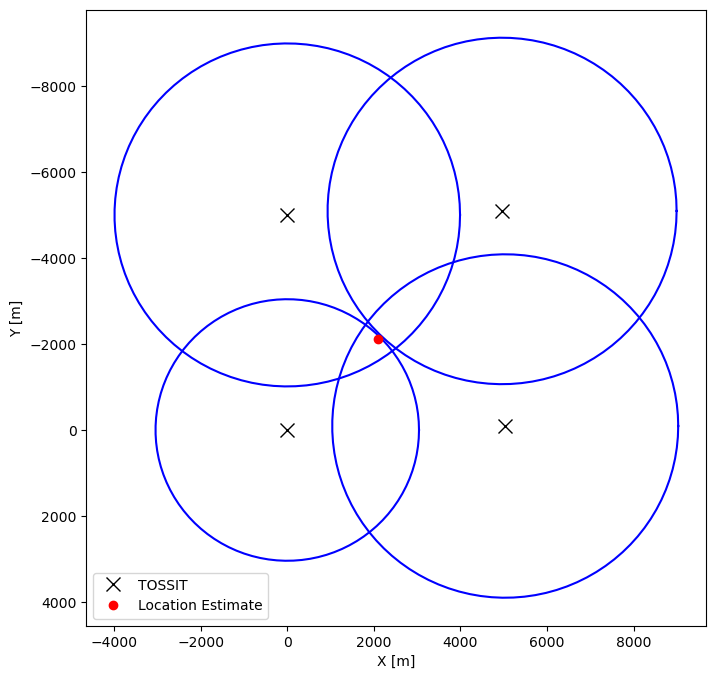

In [50]:
def circle(r, a,b):
    theta = np.linspace(0, 2*np.pi, 100)
    x = r*np.cos(theta) + a
    y = r*np.sin(theta) + b
    return x, y

TOSSIT_locations = np.asarray([config['TOSSIT']['TOSSIT_y'], config['TOSSIT']['TOSSIT_x']]).T

plt.plot(TOSSIT_locations[:,1], TOSSIT_locations[:,0], 'kx', markersize=10, label="TOSSIT")
for idx, r in enumerate(ranges):
    x, y = circle(r, TOSSIT_locations[idx,1], TOSSIT_locations[idx,0])
    plt.plot(x, y, '-b')
plt.plot(loc[1],loc[0],'ro',label="Location Estimate")
plt.gca().invert_yaxis()
plt.xlabel("X [m]")
plt.ylabel("Y [m]")
plt.legend()